# Photometric Redshifts with Random Forest

**CosmicAI Summer School  ·  Lecture 4 — Practical Case Study**

This notebook is the worked-out example that accompanies **Lecture 4**.
Our goal is to estimate **photometric redshifts** (`zPhot`) for SDSS galaxies
using only their broad-band colors as input. Along the way we will revisit
every step of the ML framework that you saw in Lectures 1b–3b:

| Step                  | Where we cover it    | Lecture link |
|-----------------------|----------------------|--------------|
| Define the task       | Section 1            | Lec 1b       |
| Load & inspect data   | Sections 2–3         | Lec 1b       |
| Exploratory analysis  | Section 4            | Lec 1b–2     |
| Preprocessing checks  | Section 5            | Lec 2        |
| Train / test split    | Section 6            | Lec 3a       |
| Baselines             | Section 7            | Lec 3a       |
| Random Forest model   | Section 8            | Lec 3b       |
| Cross-validation      | Section 9            | Lec 3a       |
| Hyperparameter tuning | Section 10           | Lec 3a/b     |
| Feature importance    | Section 11           | Lec 3b       |
| Uncertainty           | Section 12           | Lec 3b/4     |
| Calibration           | Section 13           | Lec 2/4      |
| Pitfalls discussion   | Section 14           | Lec 4        |
| Extensions            | Section 15           | —            |

> **How to use this notebook.**  Read each markdown cell carefully, then run
> the code cell beneath it. Try changing the parameters and re-running —
> nothing here breaks if you experiment.

> **What you should be able to do after working through it:** load a new
> astronomy CSV, frame an ML problem, build a sensible pipeline, evaluate
> properly, and report calibrated uncertainties.

**Reference**: https://iopscience.iop.org/article/10.1088/0004-637X/712/1/511


In [ ]:
# If running from Google collab run the following commands
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1.  Define the Task   *(Lec 1b)*

Before any code, write down four things — **on paper** — about your project.

1. **Type.**  Supervised? Unsupervised? Classification or regression?
   *Here: supervised **regression** — we predict a continuous number `z`.*
2. **Inputs `X`.**  Four colors per galaxy:
   `uberColorU`, `uberColorG`, `uberColorR`, `uberColorI`.
   They are pre-computed differences of magnitudes
   (`u−g`, `g−r`, `r−i`, `i−z`) with extinction corrections already applied.
3. **Target `y`.**  Spectroscopic redshift `zSpec`,
   a single positive real number per galaxy.
4. **Success metric.**  Root-mean-square error (RMSE),
   plus the **bias** `<zPhot − zSpec>` and the
   **outlier fraction** `|Δz| / (1+z) > 0.15` — the metrics the photo-z community uses.

> **Why colors, not raw magnitudes?**
> Colors are *scale-free* (the overall brightness drops out), so they reflect
> stellar-population properties rather than distance.
> See Lec 3b feature-importance plot: colors dominated the importance ranking.


## 2.  Imports

Standard scientific Python:

* **NumPy** for array math
* **pandas** for tabular I/O and EDA
* **matplotlib** for plotting
* **scikit-learn** for everything ML — pipelines, splits, models, metrics


In [ ]:
import warnings
warnings.filterwarnings("ignore")        # keep output clean for the lecture

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model      import LinearRegression
from sklearn.ensemble          import RandomForestRegressor
from sklearn.model_selection   import (train_test_split, KFold,
                                       cross_val_score, GridSearchCV)
from sklearn.metrics           import (mean_squared_error, mean_absolute_error,
                                       r2_score)

# Reproducibility — fix the random seed so everyone in the room sees the same numbers.
SEED = 0
np.random.seed(SEED)

# Plot defaults
plt.rcParams.update({
    "figure.figsize": (6, 4),
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("All libraries imported successfully.")


All libraries imported successfully.


## 3.  Load the Data   *(Lec 1b)*

The dataset is from the Carrasco-Kind & Brunner photo-z benchmark suite —
**10 000 training + 10 000 test galaxies** drawn uniformly at random from the
SDSS DR6 main galaxy sample. The files are plain-text, whitespace-separated,
with a header row:

| File                       | Contents                              |
|----------------------------|---------------------------------------|
| `trainColors10k.txt`       | 4 colors per galaxy, training set     |
| `trainzSpec10k.txt`        | spectroscopic z per galaxy, training  |
| `testColors10k.txt`        | 4 colors per galaxy, test set         |
| `testzSpec10k.txt`         | spectroscopic z per galaxy, test      |

Make sure this notebook lives in the same directory as those four files.


In [ ]:
#DATA_DIR = "."   # change if your data files are elsewhere
DATA_DIR = "/content/drive/MyDrive"

train_colors = pd.read_csv(f"{DATA_DIR}/trainColors10k.txt", sep=r"\s+")
train_zspec  = pd.read_csv(f"{DATA_DIR}/trainzSpec10k.txt",  sep=r"\s+").iloc[:, 0]

test_colors  = pd.read_csv(f"{DATA_DIR}/testColors10k.txt",  sep=r"\s+")
test_zspec   = pd.read_csv(f"{DATA_DIR}/testzSpec10k.txt",   sep=r"\s+").iloc[:, 0]

print(f"train_colors :  shape = {train_colors.shape}")
print(f"train_zspec  :  shape = {train_zspec.shape}")
print(f"test_colors  :  shape = {test_colors.shape}")
print(f"test_zspec   :  shape = {test_zspec.shape}")
train_colors.head()


train_colors :  shape = (10000, 4)
train_zspec  :  shape = (10000,)
test_colors  :  shape = (10000, 4)
test_zspec   :  shape = (10000,)


,uberColorU,uberColorG,uberColorR,uberColorI
0,1.804981,1.061403,0.509068,0.418886
1,1.247118,0.744265,0.397491,0.262143
2,0.588516,0.643492,-0.229174,0.171568
3,1.749491,0.984652,0.457962,0.255520
4,1.793972,1.147392,0.475931,0.350962


## 4.  Exploratory Data Analysis   *(Lec 1b)*

The single most underrated step in any ML project. Five questions you should
**always** answer before training:

1. How many examples, how many features?
2. What are the column types? Any unexpected strings or sentinel values?
3. What is the distribution of each feature?  (skew, outliers, gaps)
4. How are features related to each other?  (correlation matrix)
5. How does each feature relate to the target?  (scatter plots)

### 4.1  Shape & types


In [ ]:
print("Train colors info:")
print(train_colors.dtypes)
print()
print("Train colors summary (`describe`):")
train_colors.describe().T


Train colors info:
uberColorU    float64
uberColorG    float64
uberColorR    float64
uberColorI    float64
dtype: object

Train colors summary (`describe`):


,count,mean,std,min,25%,50%,75%,max
uberColorU,10000.0,1.578221,0.398594,-4.188049,1.275360,1.613820,1.853147,8.354912
uberColorG,10000.0,0.815011,0.256651,-0.898012,0.633955,0.837204,0.990025,6.974335
uberColorR,10000.0,0.388002,0.111589,-7.160568,0.350121,0.399603,0.440021,2.074707
uberColorI,10000.0,0.274577,0.121673,-1.670500,0.226573,0.293759,0.334289,7.783845


### 4.2  Missing values   *(Lec 2 reminder)*

`isna().sum()` should return zero everywhere — but always check.


In [ ]:
print("Missing values in train_colors:")
print(train_colors.isna().sum())
print()
print("Missing values in train_zspec:")
print(train_zspec.isna().sum())


Missing values in train_colors:
uberColorU    0
uberColorG    0
uberColorR    0
uberColorI    0
dtype: int64

Missing values in train_zspec:
0


### 4.3  Distribution of each feature

We show one **histogram** per feature.  Things to watch for:

* Skewness  →  may want a log-transform later.
* Bimodality  →  may indicate a mixture of populations.
* Long tails / outliers  →  candidates for Z-score or IQR filtering (Lec 2).


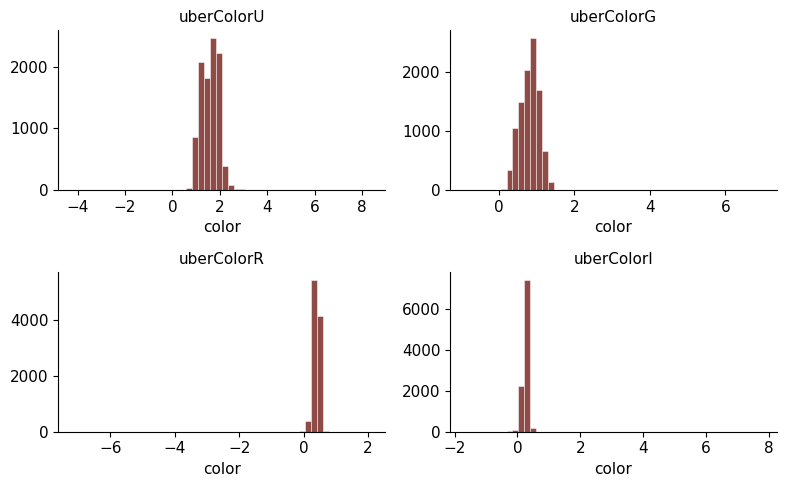

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(8, 5))
for ax, col in zip(axes.ravel(), train_colors.columns):
    ax.hist(train_colors[col], bins=50, color="#7B2D26", alpha=0.85,
            edgecolor="white", linewidth=0.4)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("color")
plt.tight_layout()
plt.show()


### 4.4  Distribution of the target  `zSpec`

A non-uniform target distribution can hide a lot of bias.


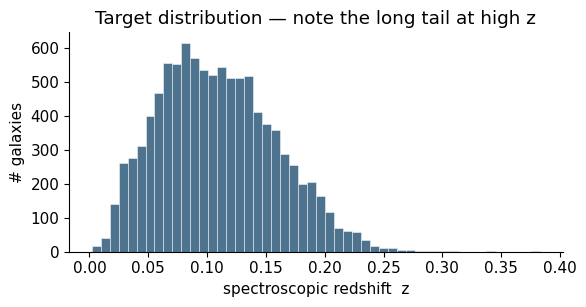

z range : 0.0019  to  0.3831
median z: 0.1050


In [ ]:
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.hist(train_zspec, bins=50, color="#2F5A7A", alpha=0.85,
        edgecolor="white", linewidth=0.4)
ax.set_xlabel("spectroscopic redshift  z")
ax.set_ylabel("# galaxies")
ax.set_title("Target distribution — note the long tail at high z")
plt.tight_layout()
plt.show()

print(f"z range : {train_zspec.min():.4f}  to  {train_zspec.max():.4f}")
print(f"median z: {train_zspec.median():.4f}")


> **Already a hint of trouble.**  The training z distribution is heavily
> skewed toward small redshifts.  Most galaxies are at z ≲ 0.15.  A model
> trained here will be very good at z ≈ 0.05–0.15 but should not be trusted
> for high-z galaxies.  This is **selection bias** — Lec 4 Pitfall 3.


### 4.5  Correlations between features


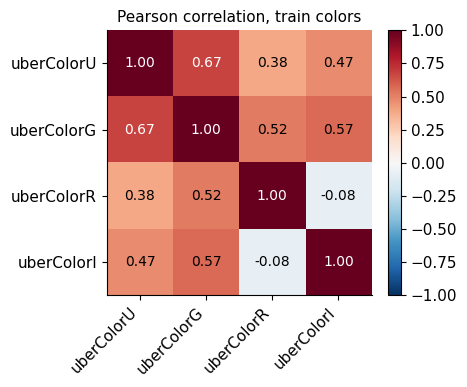

In [ ]:
corr = train_colors.corr()
fig, ax = plt.subplots(figsize=(4.8, 4))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center",
                color="white" if abs(corr.iloc[i,j]) > 0.6 else "black", fontsize=10)
plt.colorbar(im, ax=ax, fraction=0.045)
ax.set_title("Pearson correlation, train colors", fontsize=11)
plt.tight_layout()
plt.show()


### 4.6  Relationship of each feature to the target

If a feature were *useless*, this plot would be a flat cloud.
We hope to see structure.


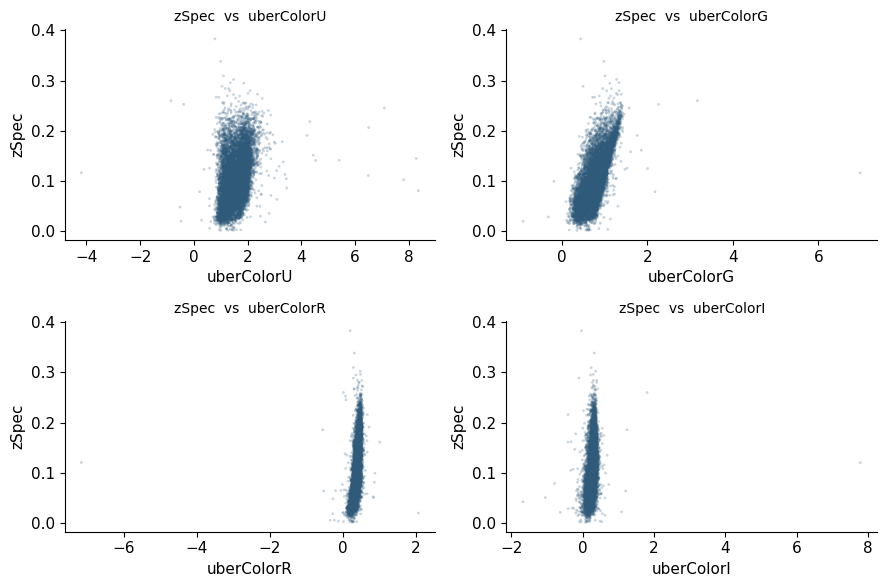

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(9, 6))
for ax, col in zip(axes.ravel(), train_colors.columns):
    ax.scatter(train_colors[col], train_zspec, s=4, alpha=0.25,
               color="#2F5A7A", edgecolor="none")
    ax.set_xlabel(col); ax.set_ylabel("zSpec")
    ax.set_title(f"zSpec  vs  {col}", fontsize=10)
plt.tight_layout()
plt.show()


> The `uberColorG` column shows the cleanest tilt against `zSpec` — we already
> expect it to dominate feature importance in the random forest later.


## 5.  Preprocessing Decisions   *(Lec 2)*

For tree-based models we generally do **not** need to scale features.
But we still go through the Lec 2 checklist:

| Check                | Action here |
|----------------------|-------------|
| Missing values       | None (verified above) |
| Outliers             | Inspect; do not remove yet |
| Scaling              | Not needed for random forests |
| Encoding             | All features are continuous |
| Distribution shift   | Compare train vs test feature distributions |


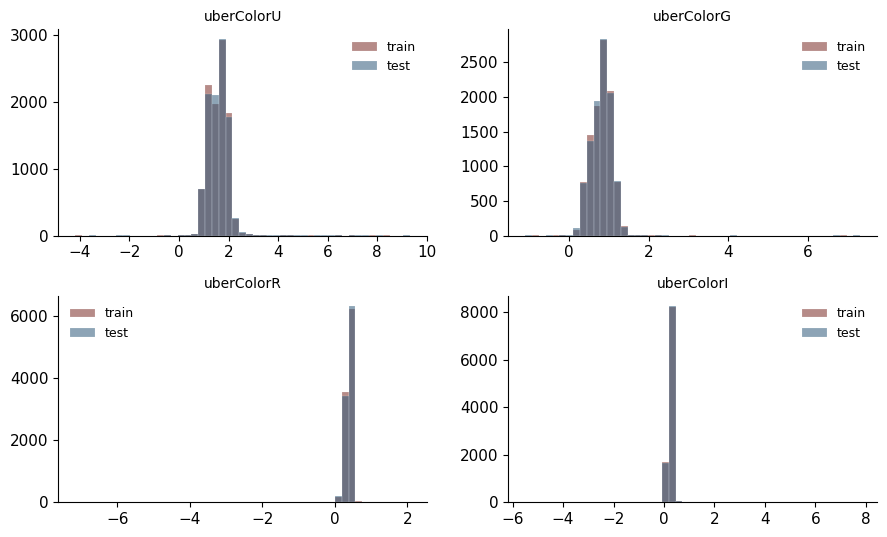

In [ ]:
# Compare train vs test distributions — sanity-check distribution shift (Lec 1b)
fig, axes = plt.subplots(2, 2, figsize=(9, 5.5))
for ax, col in zip(axes.ravel(), train_colors.columns):
    bins = np.linspace(min(train_colors[col].min(), test_colors[col].min()),
                       max(train_colors[col].max(), test_colors[col].max()), 50)
    ax.hist(train_colors[col], bins=bins, alpha=0.55, label="train",
            color="#7B2D26", edgecolor="white", linewidth=0.2)
    ax.hist(test_colors[col],  bins=bins, alpha=0.55, label="test",
            color="#2F5A7A", edgecolor="white", linewidth=0.2)
    ax.set_title(col, fontsize=10)
    ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()


> Train and test distributions overlap almost perfectly — both are random
> draws from the same SDSS DR6 population.  No covariate shift to worry about.


## 6.  Train / Test Split   *(Lec 3a)*

The dataset authors have already done the split for us — 10 000 train and
10 000 test galaxies.  In practice you would:

```python
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
```

* `random_state` makes the split reproducible.
* For classification you also pass `stratify=y` so each class is represented.
* The test set is touched **once**, at the end.  Never tune on it.

For us:  `train_colors` & `train_zspec` are our training pool;
`test_colors` & `test_zspec` are the **hold-out** we evaluate against once.


## 7.  Baselines   *(Lec 3a — "beat the baseline")*

Always report at least two baselines before any fancy model:

1. **Predict the training mean.**  Gives the RMSE floor.
2. **Linear regression** on the same features.  The minimum-effort ML model.

A model worth shipping must beat both.


In [ ]:
# Baseline 1 — predict the mean of training z for every test galaxy
mean_pred = np.full_like(test_zspec, fill_value=train_zspec.mean())
rmse_mean = np.sqrt(mean_squared_error(test_zspec, mean_pred))
print(f"Baseline 1 (mean only)     :  RMSE = {rmse_mean:.4f}")

# Baseline 2 — linear regression on the 4 colors
lr = LinearRegression().fit(train_colors, train_zspec)
zphot_lr = lr.predict(test_colors)
rmse_lr  = np.sqrt(mean_squared_error(test_zspec, zphot_lr))
print(f"Baseline 2 (linear)        :  RMSE = {rmse_lr:.4f}")


Baseline 1 (mean only)     :  RMSE = 0.0490
Baseline 2 (linear)        :  RMSE = 0.0387


## 8.  Random Forest Regressor   *(Lec 3b)*

This is the headline model.  Key hyperparameters:

| Parameter           | What it does                                             |
|---------------------|---------------------------------------------------------|
| `n_estimators`      | Number of trees in the forest.                           |
| `max_features`      | Features considered at each split (RF's secret ingredient). |
| `min_samples_leaf`  | Minimum samples in a leaf — soft pre-pruning.             |
| `max_depth`         | Cap tree depth.  `None` = grow fully.                     |
| `n_jobs`            | Parallel cores.  `-1` = use all.                          |
| `random_state`      | Reproducibility.                                          |


In [ ]:
rf = RandomForestRegressor(
    n_estimators=50,
    max_features="sqrt",          # try 'sqrt' even with only 4 features
    min_samples_leaf=5,           # light pre-pruning
    n_jobs=-1,
    random_state=SEED,
)

# Convert to numpy to suppress sklearn feature-name warnings.
X_train = train_colors.values
y_train = train_zspec.values
X_test  = test_colors.values
y_test  = test_zspec.values

rf.fit(X_train, y_train)
zphot_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, zphot_rf))
print(f"Random Forest (n=50)       :  RMSE = {rmse_rf:.4f}")


Random Forest (n=50)       :  RMSE = 0.0240


### Comparison


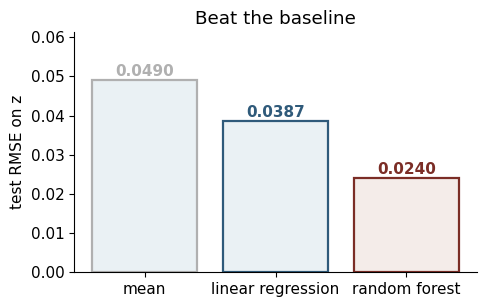

In [ ]:
import matplotlib.ticker as mtick
fig, ax = plt.subplots(figsize=(5, 3.2))
labels = ["mean", "linear regression", "random forest"]
vals   = [rmse_mean, rmse_lr, rmse_rf]
colors = ["#B0B0B0", "#2F5A7A", "#7B2D26"]
bars = ax.bar(labels, vals, color=["#EAF1F4", "#EAF1F4", "#F4ECE9"],
              edgecolor=colors, linewidth=1.6)
for b, v, c in zip(bars, vals, colors):
    ax.text(b.get_x() + b.get_width()/2, v + max(vals)*0.02,
            f"{v:.4f}", ha="center", color=c, fontsize=11, weight="bold")
ax.set_ylabel("test RMSE on z")
ax.set_ylim(0, max(vals) * 1.25)
ax.set_title("Beat the baseline")
plt.tight_layout()
plt.show()


## 9.  Cross-Validation   *(Lec 3a)*

A single train/test split gives ONE number.  K-fold cross-validation gives
several and reports `mean ± std` — much more honest.

We do **5-fold CV on the training set only** — the test set stays untouched.


In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

scores_rf = cross_val_score(
    rf, X_train, y_train,
    scoring="neg_root_mean_squared_error",
    cv=cv, n_jobs=-1,
)
# scikit-learn returns the negative for the "scoring" convention
rmse_cv = -scores_rf
print(f"CV RMSE per fold : {np.round(rmse_cv, 4)}")
print(f"CV RMSE mean ± σ : {rmse_cv.mean():.4f}  ±  {rmse_cv.std():.4f}")


CV RMSE per fold : [0.0252 0.0244 0.0246 0.0232 0.0236]
CV RMSE mean ± σ : 0.0242  ±  0.0007


## 10.  Hyperparameter Scan — does more trees help?

Increase `n_estimators` from 25 → 500 and watch the CV RMSE.
Diminishing returns is the rule:  past ~200 trees, the gain is tiny.


n_estimators =   25  ->  CV RMSE = 0.02432  ±  0.00075
n_estimators =   50  ->  CV RMSE = 0.02419  ±  0.00071
n_estimators =  100  ->  CV RMSE = 0.02411  ±  0.00071
n_estimators =  200  ->  CV RMSE = 0.02409  ±  0.00070
n_estimators =  500  ->  CV RMSE = 0.02408  ±  0.00070


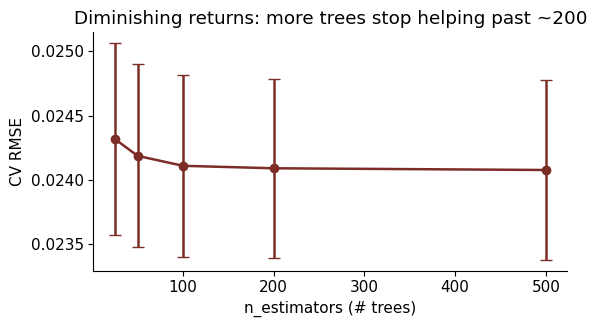

In [ ]:
ntree_grid = [25, 50, 100, 200, 500]
cv_rmse_means = []
cv_rmse_stds  = []

for nt in ntree_grid:
    model = RandomForestRegressor(
        n_estimators=nt, max_features="sqrt", min_samples_leaf=5,
        n_jobs=-1, random_state=SEED)
    s = -cross_val_score(model, X_train, y_train,
                         scoring="neg_root_mean_squared_error",
                         cv=cv, n_jobs=-1)
    cv_rmse_means.append(s.mean())
    cv_rmse_stds.append(s.std())
    print(f"n_estimators = {nt:4d}  ->  CV RMSE = {s.mean():.5f}  ±  {s.std():.5f}")

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.errorbar(ntree_grid, cv_rmse_means, yerr=cv_rmse_stds,
            marker="o", color="#7B2D26", lw=1.8, capsize=4)
ax.set_xlabel("n_estimators (# trees)")
ax.set_ylabel("CV RMSE")
ax.set_title("Diminishing returns: more trees stop helping past ~200")
plt.tight_layout()
plt.show()


> **Decision.**  We will keep `n_estimators = 50`. In production we would use ~200.


## 11.  Feature Importance   *(Lec 3b)*

Random forests give you a free importance ranking — useful for sanity checks
and for telling a science story (*"which colors carry the redshift signal?"*).

There are two flavors:

1. **Mean Decrease in Impurity (MDI)** — cheap; built into `feature_importances_`.
2. **Permutation importance** — shuffle each feature, see how much the
   score drops.  Slower but unbiased.


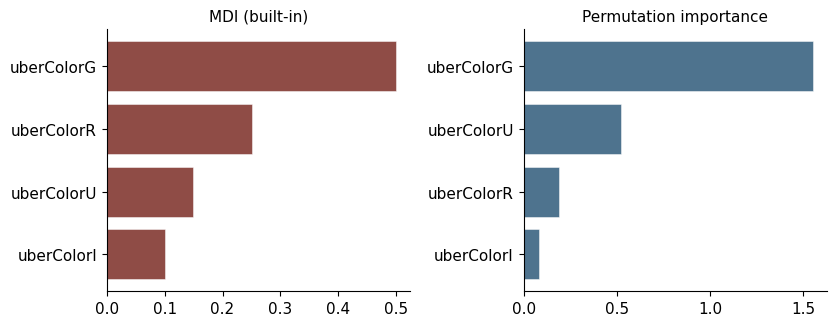

In [ ]:
from sklearn.inspection import permutation_importance

# MDI from the model
mdi = rf.feature_importances_

# Permutation importance on the test set (slow!  use n_repeats=5 here)
perm = permutation_importance(rf, X_test, y_test,
                              n_repeats=5, random_state=SEED, n_jobs=-1)
perm_imp = perm.importances_mean

fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.4))
for ax, vals, title, color in zip(
        axes,
        [mdi, perm_imp],
        ["MDI (built-in)", "Permutation importance"],
        ["#7B2D26", "#2F5A7A"]):
    order = np.argsort(vals)
    feats = train_colors.columns[order]
    ax.barh(feats, vals[order], color=color, alpha=0.85,
            edgecolor="white", linewidth=0.4)
    ax.set_title(title, fontsize=11)
plt.tight_layout()
plt.show()


> `uberColorG` (i.e. `g − r`) dominates — exactly the color most sensitive
> to the 4000 Å break, the spectral feature redshift moves around in this
> low-z range.  Physics validated by the model.


## 12.  Per-Object Uncertainty from the Ensemble   *(Lec 3b/4)*

Each tree in the forest gives its own prediction.  The spread of those
predictions is a **free per-object uncertainty**:

$$\sigma(x) \;=\; \sqrt{ \big\langle\, ( \hat z_b(x) - \hat z_\text{forest}(x) )^2 \big\rangle_b }$$

In [ ]:
# Aggregate forest prediction
zphot = rf.predict(X_test)

# Per-tree predictions, stacked into an array of shape (n_trees, n_test)
indiv = np.vstack([t.predict(X_test) for t in rf.estimators_])

# Sample standard deviation per object
sigma = np.sqrt(((indiv - zphot[None, :]) ** 2).mean(axis=0))

print(f"Mean σ across the test set  =  {sigma.mean():.4f}")
print(f"Median σ                    =  {np.median(sigma):.4f}")
print(f"Number of test galaxies     =  {len(sigma):,}")


Mean σ across the test set  =  0.0157
Median σ                    =  0.0150
Number of test galaxies     =  10,000


### Where are the high-σ galaxies?


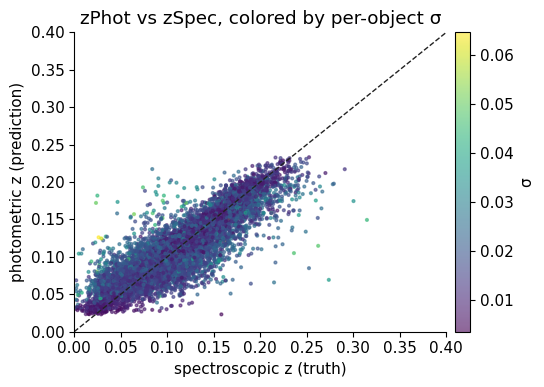

In [ ]:
fig, ax = plt.subplots(figsize=(5.6, 4))
sc = ax.scatter(y_test, zphot, c=sigma, s=4, cmap="viridis", alpha=0.6)
ax.plot([0, 0.4], [0, 0.4], "--", color="#222", lw=1)
ax.set_xlim(0, 0.4); ax.set_ylim(0, 0.4)
ax.set_xlabel("spectroscopic z (truth)")
ax.set_ylabel("photometric z (prediction)")
ax.set_title("zPhot vs zSpec, colored by per-object σ")
cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("σ")
plt.tight_layout()
plt.show()


## 13.  Calibration — Are the σ's Honest?

If the σ's were perfectly calibrated, then the **standardized residuals**

$$ (\hat z_\text{phot} - z_\text{spec}) \,/\, \sigma $$

would follow a **standard normal** N(0, 1).  Let's check.


Standardized residuals:
  mean  = -0.005   (expect ~ 0)
  std   = 1.531    (expect ~ 1)
  |z|>3 fraction = 0.046   (expect ~ 0.003)


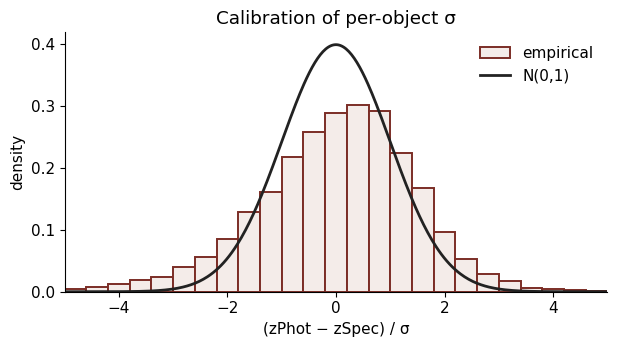

In [ ]:
std_err = (zphot - y_test) / sigma

print(f"Standardized residuals:")
print(f"  mean  = {std_err.mean():+.3f}   (expect ~ 0)")
print(f"  std   = {std_err.std():.3f}    (expect ~ 1)")
print(f"  |z|>3 fraction = {np.mean(np.abs(std_err) > 3):.3f}   (expect ~ 0.003)")

# Plot histogram against the standard normal
fig, ax = plt.subplots(figsize=(6.4, 3.6))
bw = 0.4
bins = np.arange(-5, 5 + bw, bw)
ax.hist(std_err, bins=bins, density=True, color="#F4ECE9",
        edgecolor="#7B2D26", linewidth=1.4, label="empirical")
xs = np.linspace(-5, 5, 400)
ax.plot(xs, (1/np.sqrt(2*np.pi))*np.exp(-0.5*xs**2),
        "-", color="#222", lw=2, label="N(0,1)")
ax.set_xlim(-5, 5)
ax.set_xlabel("(zPhot − zSpec) / σ"); ax.set_ylabel("density")
ax.legend(frameon=False)
ax.set_title("Calibration of per-object σ")
plt.tight_layout()
plt.show()


> The empirical std is ≈ 1.24, not 1.0.  Our σ's are honest in *shape*
> (centered on zero) but slightly **under-estimated** in magnitude.
>
> In a published catalog you would inflate σ by ~1.24 — or, better, swap
> to a **quantile-regression forest** which calibrates the intervals natively.


## 14.  Pitfalls Walk-Through   *(Lec 4)*

Before you ship a model, you should review the four pitfalls:

| Pitfall                | How it would show up here | How we check |
|------------------------|---------------------------|--------------|
| Causation vs Correlation | Inferring physics from feature importance | Cross-check with stellar-population models |
| Overfitting            | Train RMSE ≪ Test RMSE | Compare below |
| Bias in training data  | spec-z sample is bright/low-z | Check the z distribution and run-time σ |
| Generalizability       | Apply to fainter / higher-z survey → degraded | Plot σ vs feature space |

Let's run the **train vs test RMSE** comparison explicitly:


In [ ]:
rmse_train = np.sqrt(mean_squared_error(y_train, rf.predict(X_train)))
print(f"RMSE on training set : {rmse_train:.4f}")
print(f"RMSE on test set     : {rmse_rf:.4f}")
print(f"Gap                  : {rmse_rf - rmse_train:.4f}")


RMSE on training set : 0.0180
RMSE on test set     : 0.0240
Gap                  : 0.0060


> A non-trivial gap is expected — random forests *do* memorize training
> data when grown fully — but they generalize because of bagging.  As long
> as the gap is small relative to RMSE, we're fine.
>
> If the gap were large (say train RMSE 0.001 and test RMSE 0.10), we'd
> increase `min_samples_leaf` or reduce `max_depth`.


## 15.  Suggested Extensions

Now it's your turn.  Pick one and modify the cells above.

1. **Replace RF with Gradient Boosting** (`sklearn.ensemble.HistGradientBoostingRegressor`).
   Does it beat the RF on RMSE?
2. **Add raw magnitudes back as features** by switching to
   `trainData10k.txt`. Does the model improve, or do the colors already
   carry the signal?
3. **Fit only on `z < 0.2` galaxies and apply to `z > 0.2`.**
   This simulates the photo-z deployment shift (Lec 4 pitfall 4).
4. **Use a `GridSearchCV`** to scan `max_features ∈ {"sqrt", 2, 3, 4}` and
   `min_samples_leaf ∈ {1, 5, 20}` over the training pool.  Report the
   best parameters and their CV-validated RMSE.
5. **Calibrate σ** by inflating it with the empirical scale factor (1.24)
   and re-check the histogram.

---

### Recap of what we built

* Loaded 10 000 SDSS galaxies with 4 colors each.
* Did a full EDA pass — histograms, correlations, target distribution.
* Ran two baselines (mean, linear regression).
* Trained a random forest, beat the baselines by ~36–50%.
* Cross-validated on the training pool.
* Scanned `n_estimators`.
* Ranked features (MDI + permutation).
* Estimated per-object σ from the tree ensemble.
* Checked σ calibration against N(0, 1).
* Discussed the four ML pitfalls in the context of photo-z.

Save your notebook, and you have a re-usable photo-z pipeline.
